# Titanic 生存率演算法比較

目標：依序執行 6 種分類模型，輸出可比較指標，最後做統整排名。

模型清單：
- Decision Tree
- Random Forest
- Logistic Regression
- SVM
- KNN
- Gaussian Naive Bayes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


def preprocess_titanic(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 移除對本比較影響較小且缺失較多欄位
    df = df.drop(columns=["Ticket", "Cabin", "Name"], errors="ignore")

    # 缺失值補齊
    if "Age" in df.columns:
        df["Age"] = df["Age"].fillna(df["Age"].median())
    if "Fare" in df.columns:
        df["Fare"] = df["Fare"].fillna(df["Fare"].median())
    if "Embarked" in df.columns:
        df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # 特徵工程
    if {"SibSp", "Parch"}.issubset(df.columns):
        df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
        df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # 類別映射
    if "Sex" in df.columns:
        df["Sex"] = (
            df["Sex"].astype(str).str.lower().map({"male": 0, "female": 1})
        )
    if "Embarked" in df.columns:
        df["Embarked"] = (
            df["Embarked"].astype(str).str.upper().map({"S": 0, "C": 1, "Q": 2})
        )

    return df


# 讀取與前處理
train_df = pd.read_csv("train.csv")
train_df = preprocess_titanic(train_df)
train_df = train_df.dropna(subset=["Survived", "Sex", "Embarked"]).copy()

feature_cols = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "FamilySize", "IsAlone"
]
X = train_df[feature_cols].astype(float)
y = train_df["Survived"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("資料準備完成")
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}")

資料準備完成
Train: (712, 9), Valid: (179, 9)


## Step 1: Decision Tree 參數搜尋與最佳化

本區塊只執行 Decision Tree，完整保留調參過程：
1. 逐一測試多組參數組合
2. 以 5-fold CV Accuracy / F1 / ROC-AUC 比較
3. 選出最佳參數
4. 用最佳參數在驗證集做最終評估

開始執行 Decision Tree 參數搜尋...
總組合數: 180

Decision Tree 參數搜尋 Top 10:


,rank,trial,max_depth,min_samples_split,min_samples_leaf,criterion,class_weight,tree_depth,leaf_count,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,1,73,6,2,1,entropy,None,6,31,0.818881,0.732864,0.848658
1,2,74,6,10,1,entropy,None,6,26,0.817473,0.730320,0.844980
2,3,119,6,10,1,gini,balanced,6,27,0.816035,0.755151,0.840128
3,4,29,6,10,1,gini,None,6,27,0.816015,0.736298,0.842421
4,5,75,6,20,1,entropy,None,6,24,0.814646,0.730421,0.847508
5,6,31,6,2,5,gini,None,6,30,0.814636,0.737029,0.849500
6,7,32,6,10,5,gini,None,6,30,0.814636,0.737029,0.849500
7,8,118,6,2,1,gini,balanced,6,35,0.813228,0.751435,0.837476
8,9,16,4,2,10,gini,None,4,13,0.813228,0.727079,0.849565
9,10,17,4,10,10,gini,None,4,13,0.813228,0.727079,0.849565



最佳參數:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree 最佳模型驗證結果
Accuracy : 0.7877
Precision: 0.8163
Recall   : 0.5797
F1       : 0.6780
ROC-AUC  : 0.7906
Depth    : 6
Leaves   : 31

Confusion Matrix:
[[101   9]
 [ 29  40]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7769    0.9182    0.8417       110
           1     0.8163    0.5797    0.6780        69

    accuracy                         0.7877       179
   macro avg     0.7966    0.7489    0.7598       179
weighted avg     0.7921    0.7877    0.7786       179


Feature Importance:


,feature,importance
1,Sex,0.434019
0,Pclass,0.200021
5,Fare,0.128347
2,Age,0.123349
7,FamilySize,0.071879
3,SibSp,0.028530
6,Embarked,0.013856
4,Parch,0.000000
8,IsAlone,0.000000



Decision Tree 規則文字輸出:
|--- Sex <= 0.50
|   |--- Age <= 3.50
|   |   |--- SibSp <= 2.50
|   |   |   |--- weights: [0.00, 12.00] class: 1
|   |   |--- SibSp >  2.50
|   |   |   |--- FamilySize <= 6.50
|   |   |   |   |--- weights: [2.00, 0.00] class: 0
|   |   |   |--- FamilySize >  6.50
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- Fare <= 26.14
|   |   |   |   |--- weights: [10.00, 0.00] class: 0
|   |   |   |--- Fare >  26.14
|   |   |   |   |--- Fare <= 30.60
|   |   |   |   |   |--- Age <= 54.00
|   |   |   |   |   |   |--- weights: [6.00, 15.00] class: 1
|   |   |   |   |   |--- Age >  54.00
|   |   |   |   |   |   |--- weights: [4.00, 1.00] class: 0
|   |   |   |   |--- Fare >  30.60
|   |   |   |   |   |--- Fare <= 52.28
|   |   |   |   |   |   |--- weights: [18.00, 2.00] class: 0
|   |   |   |   |   |--- Fare >  52.28
|   |   |   |   |   |   |--- weights: [20.00, 15.00] class: 0
|   |   |--- Pclass >  1.50


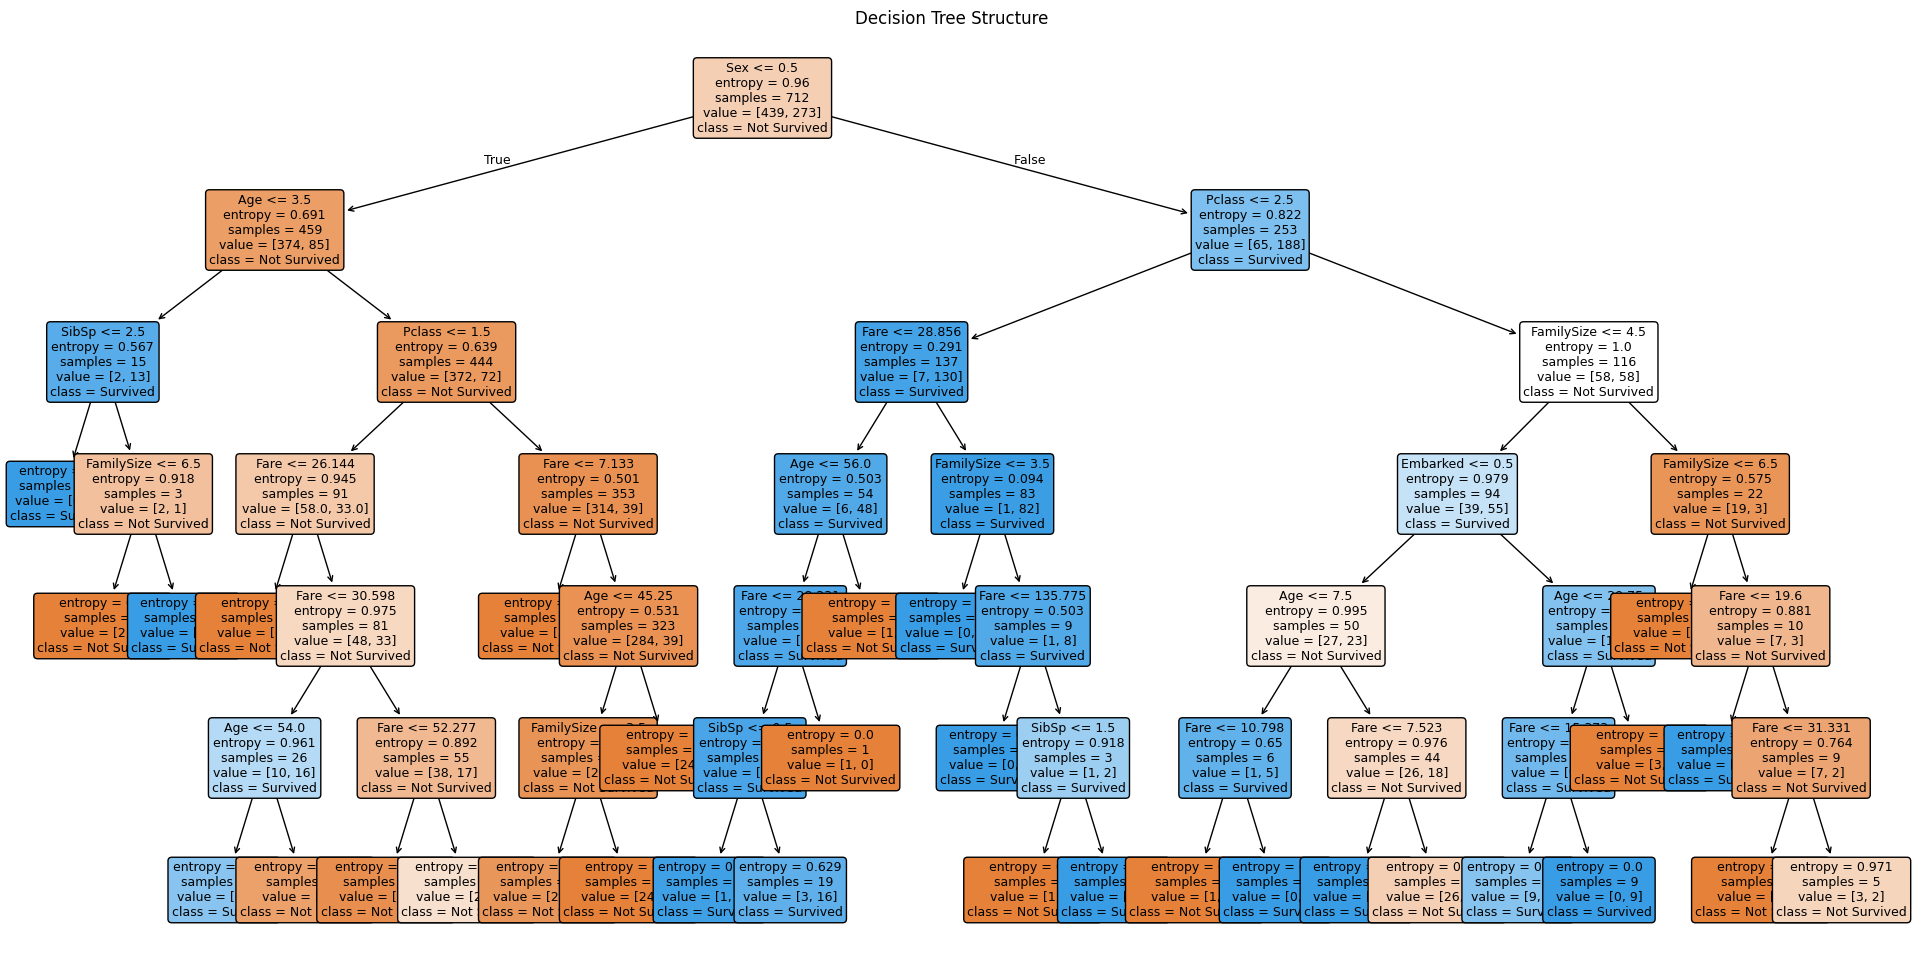


各 depth 的整體表現摘要:


,max_depth,max_depth_order,mean_accuracy,best_accuracy,mean_f1,best_f1,mean_roc_auc,best_roc_auc,avg_leaf_count,avg_tree_depth
0,3,3,0.793566,0.806185,0.711572,0.719360,0.836515,0.843656,7.444444,3.000000
1,4,4,0.798036,0.813228,0.726369,0.732988,0.849446,0.853073,13.555556,4.000000
2,5,5,0.796449,0.807594,0.724299,0.747455,0.838996,0.846351,19.555556,5.000000
3,6,6,0.799493,0.818881,0.729712,0.755151,0.840774,0.849500,26.138889,6.000000
4,None,999,0.784413,0.810421,0.724280,0.742377,0.827558,0.846715,73.805556,16.833333



各 min_samples_leaf 的整體表現摘要:


,min_samples_leaf,mean_accuracy,best_accuracy,mean_f1,avg_leaf_count,avg_tree_depth
0,1,0.798977,0.818881,0.727324,35.766667,7.833333
1,5,0.795359,0.814636,0.724845,27.033333,6.766667
2,10,0.788837,0.813228,0.717570,21.500000,6.300000



最接近最佳模型的前 15 組參數:


,rank,max_depth,min_samples_leaf,min_samples_split,tree_depth,leaf_count,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,1,6,1,2,6,31,0.818881,0.732864,0.848658
1,2,6,1,10,6,26,0.817473,0.730320,0.844980
2,3,6,1,10,6,27,0.816035,0.755151,0.840128
3,4,6,1,10,6,27,0.816015,0.736298,0.842421
4,5,6,1,20,6,24,0.814646,0.730421,0.847508
5,6,6,5,2,6,30,0.814636,0.737029,0.849500
6,7,6,5,10,6,30,0.814636,0.737029,0.849500
7,8,6,1,2,6,35,0.813228,0.751435,0.837476
8,9,4,10,2,4,13,0.813228,0.727079,0.849565
9,10,4,10,10,4,13,0.813228,0.727079,0.849565


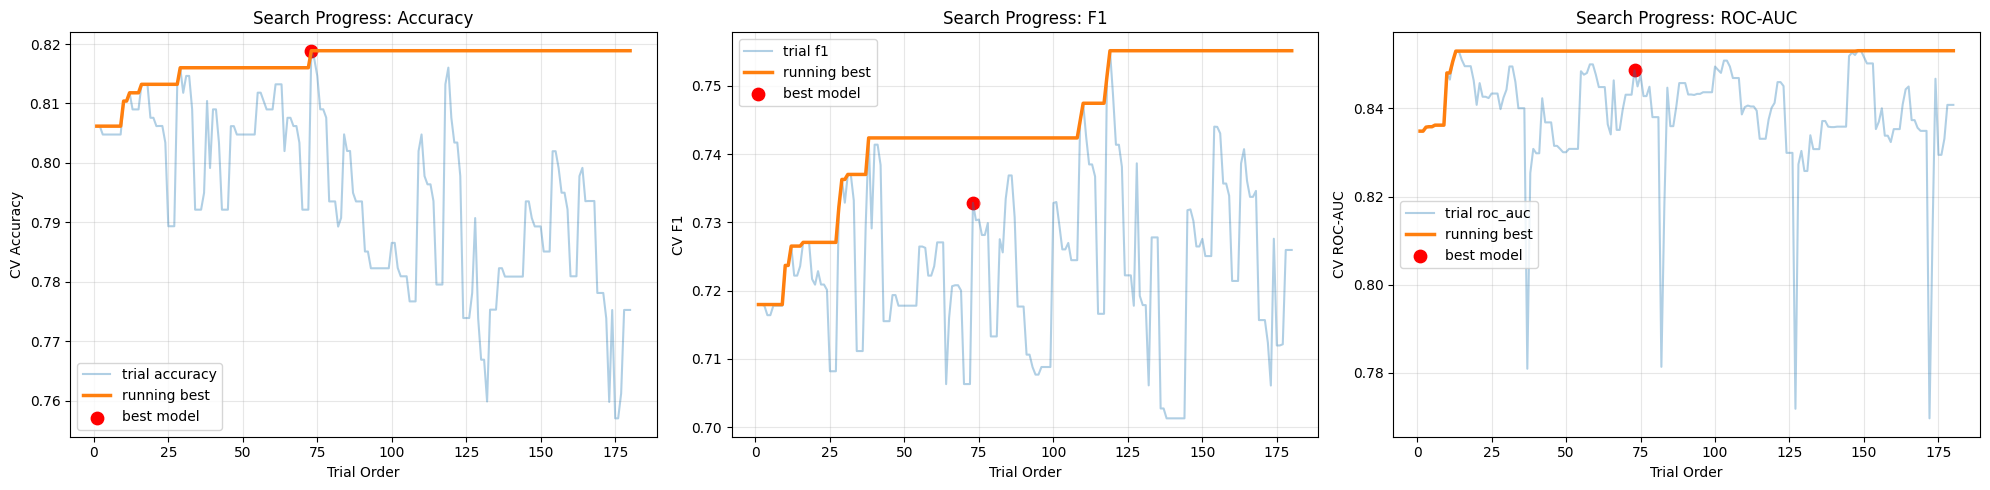

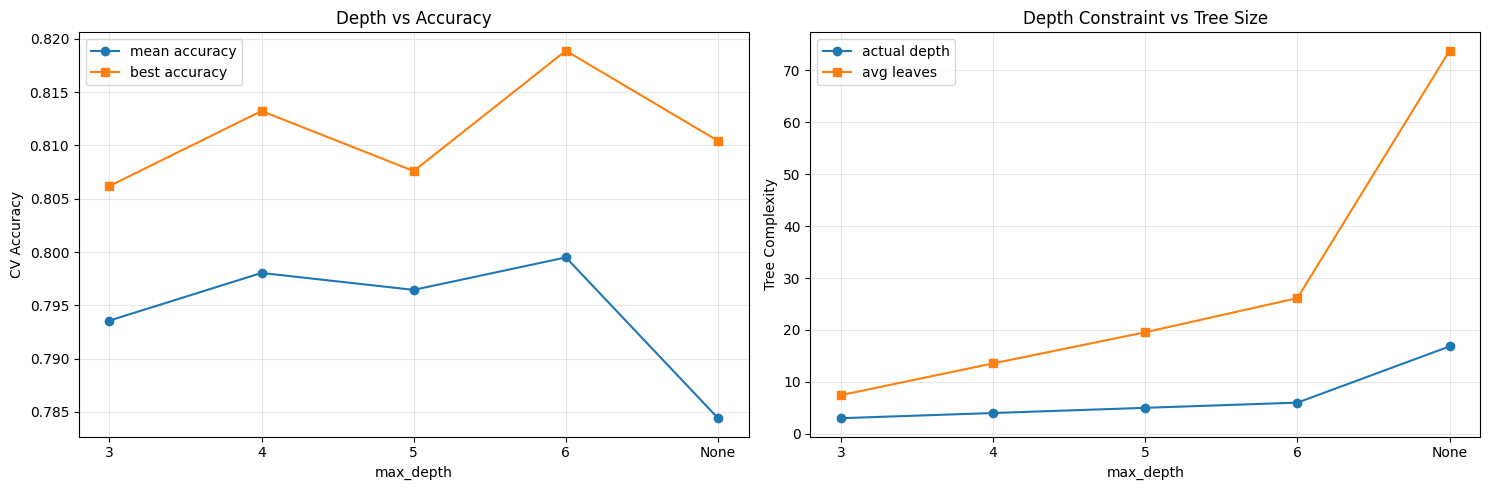

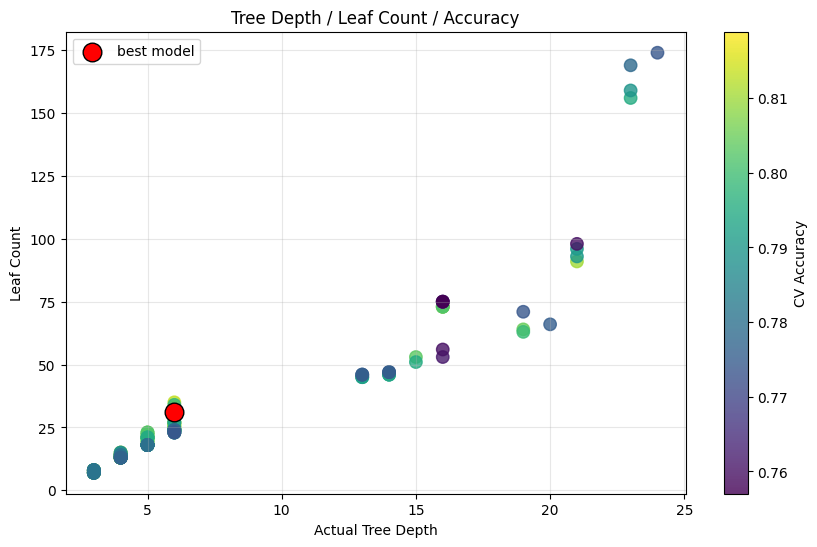


已輸出: decision_tree_search_results.csv, decision_tree_best_result.csv


In [4]:
from sklearn.model_selection import ParameterGrid
from sklearn.tree import export_text, plot_tree

# Decision Tree 參數搜尋空間
param_grid = {
    "max_depth": [3, 4, 5, 6, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search_rows = []

print("開始執行 Decision Tree 參數搜尋...")
all_combinations = list(ParameterGrid(param_grid))
print(f"總組合數: {len(all_combinations)}")

for idx, p in enumerate(all_combinations, start=1):
    model = DecisionTreeClassifier(random_state=42, **p)
    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        n_jobs=-1,
    )

    model.fit(X_train, y_train)
    max_depth_value = p["max_depth"] if p["max_depth"] is not None else "None"
    class_weight_value = p["class_weight"] if p["class_weight"] is not None else "None"

    search_rows.append({
        "trial": idx,
        "max_depth": max_depth_value,
        "max_depth_order": 999 if p["max_depth"] is None else p["max_depth"],
        "min_samples_split": p["min_samples_split"],
        "min_samples_leaf": p["min_samples_leaf"],
        "criterion": p["criterion"],
        "class_weight": class_weight_value,
        "tree_depth": model.get_depth(),
        "leaf_count": model.get_n_leaves(),
        "params": p,
        "cv_accuracy_mean": np.mean(cv_result["test_accuracy"]),
        "cv_accuracy_std": np.std(cv_result["test_accuracy"]),
        "cv_f1_mean": np.mean(cv_result["test_f1"]),
        "cv_roc_auc_mean": np.mean(cv_result["test_roc_auc"]),
    })

search_df = pd.DataFrame(search_rows)
search_df["running_best_accuracy"] = search_df["cv_accuracy_mean"].cummax()
search_df["running_best_f1"] = search_df["cv_f1_mean"].cummax()
search_df["running_best_roc_auc"] = search_df["cv_roc_auc_mean"].cummax()

search_df = search_df.sort_values(
    by=["cv_accuracy_mean", "cv_f1_mean", "cv_roc_auc_mean"],
    ascending=False,
).reset_index(drop=True)
search_df["rank"] = np.arange(1, len(search_df) + 1)

print("\nDecision Tree 參數搜尋 Top 10:")
display(
    search_df[[
        "rank",
        "trial",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "criterion",
        "class_weight",
        "tree_depth",
        "leaf_count",
        "cv_accuracy_mean",
        "cv_f1_mean",
        "cv_roc_auc_mean",
    ]].head(10)
 )

best_dt_params = search_df.loc[0, "params"]
print("\n最佳參數:")
print(best_dt_params)

best_dt = DecisionTreeClassifier(random_state=42, **best_dt_params)
best_dt.fit(X_train, y_train)

y_pred = best_dt.predict(X_valid)
if hasattr(best_dt, "predict_proba"):
    y_score = best_dt.predict_proba(X_valid)[:, 1]
else:
    y_score = best_dt.decision_function(X_valid)

dt_result = {
    "Model": "Decision Tree",
    "Best_Params": best_dt_params,
    "Valid_Accuracy": accuracy_score(y_valid, y_pred),
    "Valid_Precision": precision_score(y_valid, y_pred, zero_division=0),
    "Valid_Recall": recall_score(y_valid, y_pred, zero_division=0),
    "Valid_F1": f1_score(y_valid, y_pred, zero_division=0),
    "Valid_ROC_AUC": roc_auc_score(y_valid, y_score),
    "Tree_Depth": best_dt.get_depth(),
    "Leaf_Count": best_dt.get_n_leaves(),
    "Confusion_Matrix": confusion_matrix(y_valid, y_pred),
    "Classification_Report": classification_report(y_valid, y_pred, digits=4),
}

print("\nDecision Tree 最佳模型驗證結果")
print(f"Accuracy : {dt_result['Valid_Accuracy']:.4f}")
print(f"Precision: {dt_result['Valid_Precision']:.4f}")
print(f"Recall   : {dt_result['Valid_Recall']:.4f}")
print(f"F1       : {dt_result['Valid_F1']:.4f}")
print(f"ROC-AUC  : {dt_result['Valid_ROC_AUC']:.4f}")
print(f"Depth    : {dt_result['Tree_Depth']}")
print(f"Leaves   : {dt_result['Leaf_Count']}")

print("\nConfusion Matrix:")
print(dt_result["Confusion_Matrix"])
print("\nClassification Report:")
print(dt_result["Classification_Report"])

# 顯示重要特徵
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_dt.feature_importances_,
}).sort_values("importance", ascending=False)

print("\nFeature Importance:")
display(importance_df)

tree_rules = export_text(
    best_dt,
    feature_names=list(X_train.columns),
    decimals=2,
    show_weights=True,
 )
print("\nDecision Tree 規則文字輸出:")
print(tree_rules)

plt.figure(figsize=(24, 12))
plot_tree(
    best_dt,
    feature_names=list(X_train.columns),
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9,
 )
plt.title("Decision Tree Structure")
plt.show()

depth_summary = (
    search_df.groupby(["max_depth", "max_depth_order"], as_index=False)
    .agg(
        mean_accuracy=("cv_accuracy_mean", "mean"),
        best_accuracy=("cv_accuracy_mean", "max"),
        mean_f1=("cv_f1_mean", "mean"),
        best_f1=("cv_f1_mean", "max"),
        mean_roc_auc=("cv_roc_auc_mean", "mean"),
        best_roc_auc=("cv_roc_auc_mean", "max"),
        avg_leaf_count=("leaf_count", "mean"),
        avg_tree_depth=("tree_depth", "mean"),
    )
    .sort_values("max_depth_order")
    .reset_index(drop=True)
 )

leaf_summary = (
    search_df.groupby("min_samples_leaf", as_index=False)
    .agg(
        mean_accuracy=("cv_accuracy_mean", "mean"),
        best_accuracy=("cv_accuracy_mean", "max"),
        mean_f1=("cv_f1_mean", "mean"),
        avg_leaf_count=("leaf_count", "mean"),
        avg_tree_depth=("tree_depth", "mean"),
    )
    .sort_values("min_samples_leaf")
 )

top_leaf_summary = search_df.nsmallest(15, "rank")[[
    "rank",
    "max_depth",
    "min_samples_leaf",
    "min_samples_split",
    "tree_depth",
    "leaf_count",
    "cv_accuracy_mean",
    "cv_f1_mean",
    "cv_roc_auc_mean",
]].copy()

print("\n各 depth 的整體表現摘要:")
display(depth_summary)
print("\n各 min_samples_leaf 的整體表現摘要:")
display(leaf_summary)
print("\n最接近最佳模型的前 15 組參數:")
display(top_leaf_summary)

best_row = search_df.iloc[0]
plot_search_progress = search_df.sort_values("trial").copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(plot_search_progress["trial"], plot_search_progress["cv_accuracy_mean"], alpha=0.35, label="trial accuracy")
axes[0].plot(plot_search_progress["trial"], plot_search_progress["running_best_accuracy"], linewidth=2.5, label="running best")
axes[0].scatter(best_row["trial"], best_row["cv_accuracy_mean"], color="red", s=80, label="best model")
axes[0].set_title("Search Progress: Accuracy")
axes[0].set_xlabel("Trial Order")
axes[0].set_ylabel("CV Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(plot_search_progress["trial"], plot_search_progress["cv_f1_mean"], alpha=0.35, label="trial f1")
axes[1].plot(plot_search_progress["trial"], plot_search_progress["running_best_f1"], linewidth=2.5, label="running best")
axes[1].scatter(best_row["trial"], best_row["cv_f1_mean"], color="red", s=80, label="best model")
axes[1].set_title("Search Progress: F1")
axes[1].set_xlabel("Trial Order")
axes[1].set_ylabel("CV F1")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(plot_search_progress["trial"], plot_search_progress["cv_roc_auc_mean"], alpha=0.35, label="trial roc_auc")
axes[2].plot(plot_search_progress["trial"], plot_search_progress["running_best_roc_auc"], linewidth=2.5, label="running best")
axes[2].scatter(best_row["trial"], best_row["cv_roc_auc_mean"], color="red", s=80, label="best model")
axes[2].set_title("Search Progress: ROC-AUC")
axes[2].set_xlabel("Trial Order")
axes[2].set_ylabel("CV ROC-AUC")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(depth_summary["max_depth"].astype(str), depth_summary["mean_accuracy"], marker="o", label="mean accuracy")
axes[0].plot(depth_summary["max_depth"].astype(str), depth_summary["best_accuracy"], marker="s", label="best accuracy")
axes[0].set_title("Depth vs Accuracy")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("CV Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(depth_summary["max_depth"].astype(str), depth_summary["avg_tree_depth"], marker="o", label="actual depth")
axes[1].plot(depth_summary["max_depth"].astype(str), depth_summary["avg_leaf_count"], marker="s", label="avg leaves")
axes[1].set_title("Depth Constraint vs Tree Size")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Tree Complexity")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    search_df["tree_depth"],
    search_df["leaf_count"],
    c=search_df["cv_accuracy_mean"],
    cmap="viridis",
    s=80,
    alpha=0.8,
 )
plt.scatter(
    best_row["tree_depth"],
    best_row["leaf_count"],
    color="red",
    s=180,
    edgecolors="black",
    label="best model",
 )
plt.title("Tree Depth / Leaf Count / Accuracy")
plt.xlabel("Actual Tree Depth")
plt.ylabel("Leaf Count")
plt.grid(alpha=0.3)
plt.legend()
plt.colorbar(scatter, label="CV Accuracy")
plt.show()

# 輸出檔案，方便整理報告
search_df.to_csv("decision_tree_search_results.csv", index=False, encoding="utf-8-sig")
pd.DataFrame([{
    "model": dt_result["Model"],
    "best_params": str(dt_result["Best_Params"]),
    "valid_accuracy": dt_result["Valid_Accuracy"],
    "valid_precision": dt_result["Valid_Precision"],
    "valid_recall": dt_result["Valid_Recall"],
    "valid_f1": dt_result["Valid_F1"],
    "valid_roc_auc": dt_result["Valid_ROC_AUC"],
    "tree_depth": dt_result["Tree_Depth"],
    "leaf_count": dt_result["Leaf_Count"],
}]).to_csv("decision_tree_best_result.csv", index=False, encoding="utf-8-sig")

print("\n已輸出: decision_tree_search_results.csv, decision_tree_best_result.csv")

## Step 2: Random Forest 參數搜尋與最佳化

本區塊只執行 Random Forest，針對關鍵參數調整：
1. n_estimators（樹的數量）
2. max_depth（每棵樹深度）
3. min_samples_split / min_samples_leaf（抑制過擬合）
4. max_features（每次分裂可用特徵）
5. class_weight（處理類別不平衡）
6. 以 5-fold CV Accuracy / F1 / ROC-AUC 選出最佳模型

開始執行 Random Forest 參數搜尋...
總組合數: 192

Random Forest 參數搜尋 Top 10:


,rank,trial,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,class_weight,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,1,149,300,8,10,1,sqrt,balanced,0.828711,0.772262,0.880720
1,2,161,300,8,10,1,log2,balanced,0.828711,0.772262,0.880720
2,3,150,500,8,10,1,sqrt,balanced,0.828711,0.773077,0.879264
3,4,162,500,8,10,1,log2,balanced,0.828711,0.773077,0.879264
4,5,174,500,None,10,1,sqrt,balanced,0.824476,0.769553,0.880465
5,6,186,500,None,10,1,log2,balanced,0.824476,0.769553,0.880465
6,7,148,100,8,10,1,sqrt,balanced,0.823097,0.765048,0.877363
7,8,160,100,8,10,1,log2,balanced,0.823097,0.765048,0.877363
8,9,147,500,8,2,1,sqrt,balanced,0.823087,0.765150,0.876023
9,10,159,500,8,2,1,log2,balanced,0.823087,0.765150,0.876023



Random Forest 最佳參數:
{'class_weight': 'balanced', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}

Random Forest 最佳模型驗證結果
Accuracy : 0.7933
Precision: 0.7286
Recall   : 0.7391
F1       : 0.7338
ROC-AUC  : 0.8420

Confusion Matrix:
[[91 19]
 [18 51]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8349    0.8273    0.8311       110
           1     0.7286    0.7391    0.7338        69

    accuracy                         0.7933       179
   macro avg     0.7817    0.7832    0.7824       179
weighted avg     0.7939    0.7933    0.7936       179


Random Forest Feature Importance:


,feature,importance
1,Sex,0.385245
5,Fare,0.206111
2,Age,0.148538
0,Pclass,0.111630
7,FamilySize,0.059539
6,Embarked,0.030664
3,SibSp,0.024830
4,Parch,0.019997
8,IsAlone,0.013446


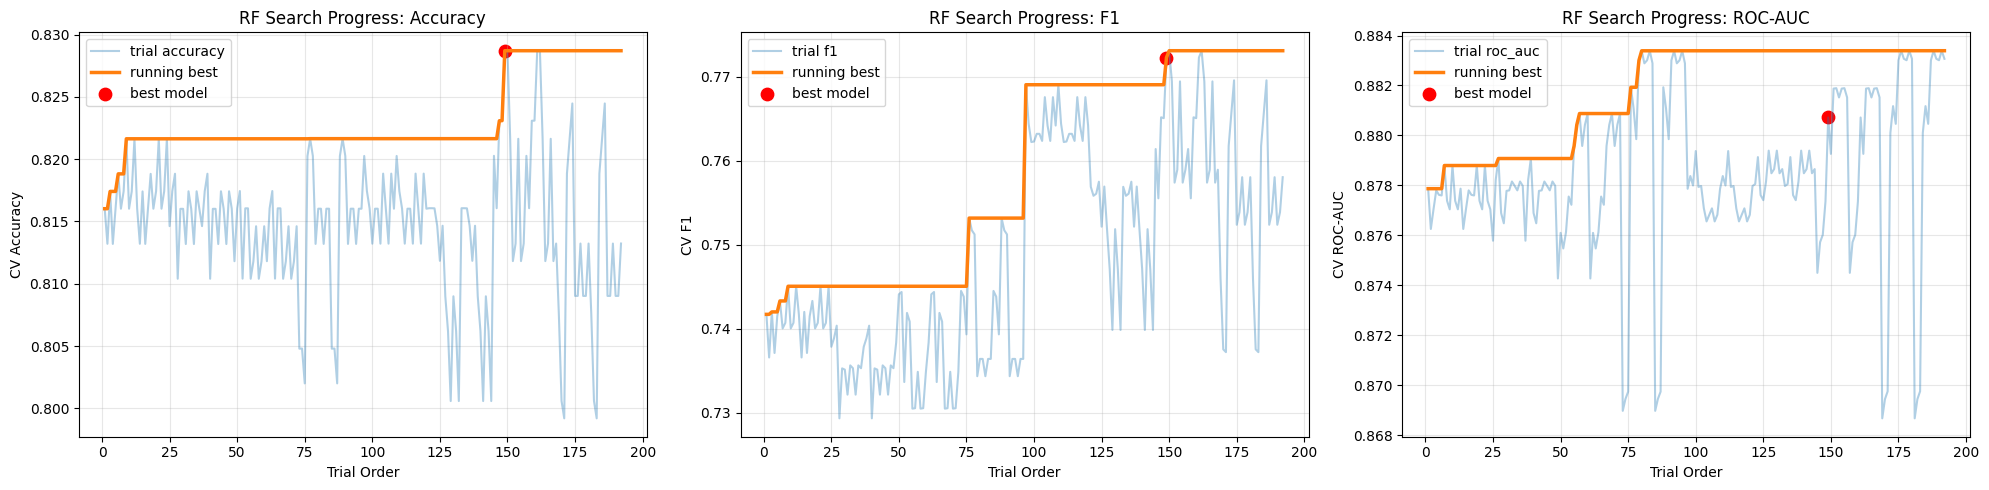

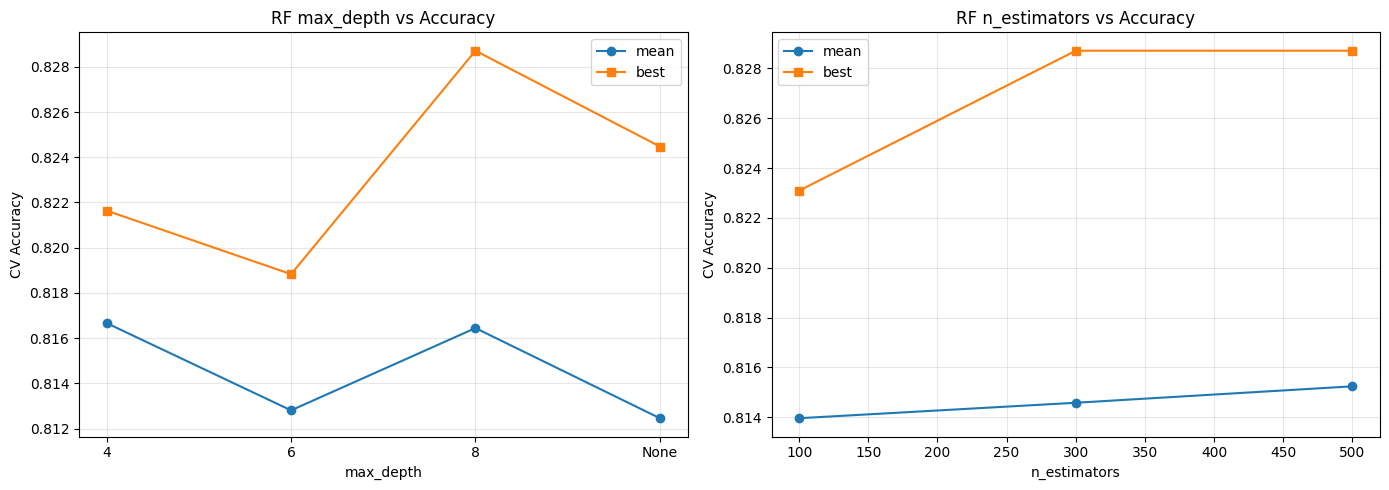


已輸出: random_forest_search_results.csv, random_forest_best_result.csv


In [5]:
from sklearn.model_selection import ParameterGrid

rf_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_search_rows = []

print("開始執行 Random Forest 參數搜尋...")
rf_all_combinations = list(ParameterGrid(rf_param_grid))
print(f"總組合數: {len(rf_all_combinations)}")

for idx, p in enumerate(rf_all_combinations, start=1):
    rf_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **p,
    )
    rf_cv_result = cross_validate(
        rf_model,
        X_train,
        y_train,
        cv=rf_cv,
        scoring=["accuracy", "f1", "roc_auc"],
        n_jobs=-1,
    )

    rf_model.fit(X_train, y_train)
    rf_search_rows.append({
        "trial": idx,
        "n_estimators": p["n_estimators"],
        "max_depth": "None" if p["max_depth"] is None else p["max_depth"],
        "max_depth_order": 999 if p["max_depth"] is None else p["max_depth"],
        "min_samples_split": p["min_samples_split"],
        "min_samples_leaf": p["min_samples_leaf"],
        "max_features": p["max_features"],
        "class_weight": "None" if p["class_weight"] is None else p["class_weight"],
        "params": p,
        "cv_accuracy_mean": np.mean(rf_cv_result["test_accuracy"]),
        "cv_accuracy_std": np.std(rf_cv_result["test_accuracy"]),
        "cv_f1_mean": np.mean(rf_cv_result["test_f1"]),
        "cv_roc_auc_mean": np.mean(rf_cv_result["test_roc_auc"]),
    })

rf_search_df = pd.DataFrame(rf_search_rows)
rf_search_df["running_best_accuracy"] = rf_search_df["cv_accuracy_mean"].cummax()
rf_search_df["running_best_f1"] = rf_search_df["cv_f1_mean"].cummax()
rf_search_df["running_best_roc_auc"] = rf_search_df["cv_roc_auc_mean"].cummax()

rf_search_df = rf_search_df.sort_values(
    by=["cv_accuracy_mean", "cv_f1_mean", "cv_roc_auc_mean"],
    ascending=False,
).reset_index(drop=True)
rf_search_df["rank"] = np.arange(1, len(rf_search_df) + 1)

print("\nRandom Forest 參數搜尋 Top 10:")
display(
    rf_search_df[[
        "rank",
        "trial",
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "max_features",
        "class_weight",
        "cv_accuracy_mean",
        "cv_f1_mean",
        "cv_roc_auc_mean",
    ]].head(10)
)

rf_best_params = rf_search_df.loc[0, "params"]
print("\nRandom Forest 最佳參數:")
print(rf_best_params)

best_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **rf_best_params,
)
best_rf.fit(X_train, y_train)

rf_y_pred = best_rf.predict(X_valid)
rf_y_score = best_rf.predict_proba(X_valid)[:, 1]

rf_result = {
    "Model": "Random Forest",
    "Best_Params": rf_best_params,
    "Valid_Accuracy": accuracy_score(y_valid, rf_y_pred),
    "Valid_Precision": precision_score(y_valid, rf_y_pred, zero_division=0),
    "Valid_Recall": recall_score(y_valid, rf_y_pred, zero_division=0),
    "Valid_F1": f1_score(y_valid, rf_y_pred, zero_division=0),
    "Valid_ROC_AUC": roc_auc_score(y_valid, rf_y_score),
    "Confusion_Matrix": confusion_matrix(y_valid, rf_y_pred),
    "Classification_Report": classification_report(y_valid, rf_y_pred, digits=4),
}

print("\nRandom Forest 最佳模型驗證結果")
print(f"Accuracy : {rf_result['Valid_Accuracy']:.4f}")
print(f"Precision: {rf_result['Valid_Precision']:.4f}")
print(f"Recall   : {rf_result['Valid_Recall']:.4f}")
print(f"F1       : {rf_result['Valid_F1']:.4f}")
print(f"ROC-AUC  : {rf_result['Valid_ROC_AUC']:.4f}")

print("\nConfusion Matrix:")
print(rf_result["Confusion_Matrix"])
print("\nClassification Report:")
print(rf_result["Classification_Report"])

rf_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_,
}).sort_values("importance", ascending=False)

print("\nRandom Forest Feature Importance:")
display(rf_importance_df)

rf_best_row = rf_search_df.iloc[0]
rf_progress_df = rf_search_df.sort_values("trial")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(rf_progress_df["trial"], rf_progress_df["cv_accuracy_mean"], alpha=0.35, label="trial accuracy")
axes[0].plot(rf_progress_df["trial"], rf_progress_df["running_best_accuracy"], linewidth=2.5, label="running best")
axes[0].scatter(rf_best_row["trial"], rf_best_row["cv_accuracy_mean"], color="red", s=80, label="best model")
axes[0].set_title("RF Search Progress: Accuracy")
axes[0].set_xlabel("Trial Order")
axes[0].set_ylabel("CV Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(rf_progress_df["trial"], rf_progress_df["cv_f1_mean"], alpha=0.35, label="trial f1")
axes[1].plot(rf_progress_df["trial"], rf_progress_df["running_best_f1"], linewidth=2.5, label="running best")
axes[1].scatter(rf_best_row["trial"], rf_best_row["cv_f1_mean"], color="red", s=80, label="best model")
axes[1].set_title("RF Search Progress: F1")
axes[1].set_xlabel("Trial Order")
axes[1].set_ylabel("CV F1")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(rf_progress_df["trial"], rf_progress_df["cv_roc_auc_mean"], alpha=0.35, label="trial roc_auc")
axes[2].plot(rf_progress_df["trial"], rf_progress_df["running_best_roc_auc"], linewidth=2.5, label="running best")
axes[2].scatter(rf_best_row["trial"], rf_best_row["cv_roc_auc_mean"], color="red", s=80, label="best model")
axes[2].set_title("RF Search Progress: ROC-AUC")
axes[2].set_xlabel("Trial Order")
axes[2].set_ylabel("CV ROC-AUC")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

rf_depth_summary = (
    rf_search_df.groupby(["max_depth", "max_depth_order"], as_index=False)
    .agg(
        mean_accuracy=("cv_accuracy_mean", "mean"),
        best_accuracy=("cv_accuracy_mean", "max"),
    )
    .sort_values("max_depth_order")
    .reset_index(drop=True)
)

rf_trees_summary = (
    rf_search_df.groupby("n_estimators", as_index=False)
    .agg(
        mean_accuracy=("cv_accuracy_mean", "mean"),
        best_accuracy=("cv_accuracy_mean", "max"),
    )
    .sort_values("n_estimators")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rf_depth_summary["max_depth"].astype(str), rf_depth_summary["mean_accuracy"], marker="o", label="mean")
axes[0].plot(rf_depth_summary["max_depth"].astype(str), rf_depth_summary["best_accuracy"], marker="s", label="best")
axes[0].set_title("RF max_depth vs Accuracy")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("CV Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(rf_trees_summary["n_estimators"], rf_trees_summary["mean_accuracy"], marker="o", label="mean")
axes[1].plot(rf_trees_summary["n_estimators"], rf_trees_summary["best_accuracy"], marker="s", label="best")
axes[1].set_title("RF n_estimators vs Accuracy")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("CV Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

rf_search_df.to_csv("random_forest_search_results.csv", index=False, encoding="utf-8-sig")
pd.DataFrame([{
    "model": rf_result["Model"],
    "best_params": str(rf_result["Best_Params"]),
    "valid_accuracy": rf_result["Valid_Accuracy"],
    "valid_precision": rf_result["Valid_Precision"],
    "valid_recall": rf_result["Valid_Recall"],
    "valid_f1": rf_result["Valid_F1"],
    "valid_roc_auc": rf_result["Valid_ROC_AUC"],
}]).to_csv("random_forest_best_result.csv", index=False, encoding="utf-8-sig")

print("\n已輸出: random_forest_search_results.csv, random_forest_best_result.csv")

## Step 3: Logistic Regression 參數搜尋與最佳化

本區塊只執行 Logistic Regression，針對關鍵參數調整：
1. C（正則化強度）
2. penalty（L1 / L2）
3. solver（優化器）
4. max_iter（迭代上限）
5. class_weight（處理類別不平衡）
6. 以 5-fold CV Accuracy / F1 / ROC-AUC 選出最佳模型

開始執行 Logistic Regression 參數搜尋...
總組合數: 1000


/Users/jackpan/development/python/DataMiningExercises/DataMiningExercises/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jackpan/development/python/DataMiningExercises/DataMiningExercises/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jackpan/development/python/DataMiningExercises/DataMiningExercises/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jackpan/development/python/DataMiningExercises/DataMiningExercises/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/jackpan/development/python/DataMiningExer


Logistic Regression 參數搜尋 Top 10:


,rank,trial,C,penalty,solver,max_iter,class_weight,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,1,5,0.01,l2,saga,1,None,0.801950,0.716872,0.851213
1,2,407,1.00,l2,liblinear,6,None,0.799163,0.729435,0.856455
2,3,412,1.00,l2,liblinear,11,None,0.799163,0.729435,0.856455
3,4,417,1.00,l2,liblinear,16,None,0.799163,0.729435,0.856455
4,5,422,1.00,l2,liblinear,21,None,0.799163,0.729435,0.856455
5,6,427,1.00,l2,liblinear,26,None,0.799163,0.729435,0.856455
6,7,432,1.00,l2,liblinear,31,None,0.799163,0.729435,0.856455
7,8,437,1.00,l2,liblinear,36,None,0.799163,0.729435,0.856455
8,9,442,1.00,l2,liblinear,41,None,0.799163,0.729435,0.856455
9,10,447,1.00,l2,liblinear,46,None,0.799163,0.729435,0.856455



Logistic Regression 最佳參數:
{'model__C': 0.01, 'model__class_weight': None, 'model__max_iter': 1, 'model__solver': 'saga', 'model__penalty': 'l2'}

Logistic Regression 最佳模型驗證結果
Accuracy : 0.8101
Precision: 0.8431
Recall   : 0.6232
F1       : 0.7167
ROC-AUC  : 0.8353

Confusion Matrix:
[[102   8]
 [ 26  43]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7969    0.9273    0.8571       110
           1     0.8431    0.6232    0.7167        69

    accuracy                         0.8101       179
   macro avg     0.8200    0.7752    0.7869       179
weighted avg     0.8147    0.8101    0.8030       179


Logistic Regression 係數重要性:


/Users/jackpan/development/python/DataMiningExercises/DataMiningExercises/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,feature,coefficient,abs_coefficient
1,Sex,0.727665,0.727665
0,Pclass,-0.413462,0.413462
5,Fare,0.313684,0.313684
2,Age,-0.205428,0.205428
3,SibSp,-0.196941,0.196941
6,Embarked,0.179504,0.179504
7,FamilySize,-0.131686,0.131686
8,IsAlone,-0.106649,0.106649
4,Parch,-0.000424,0.000424


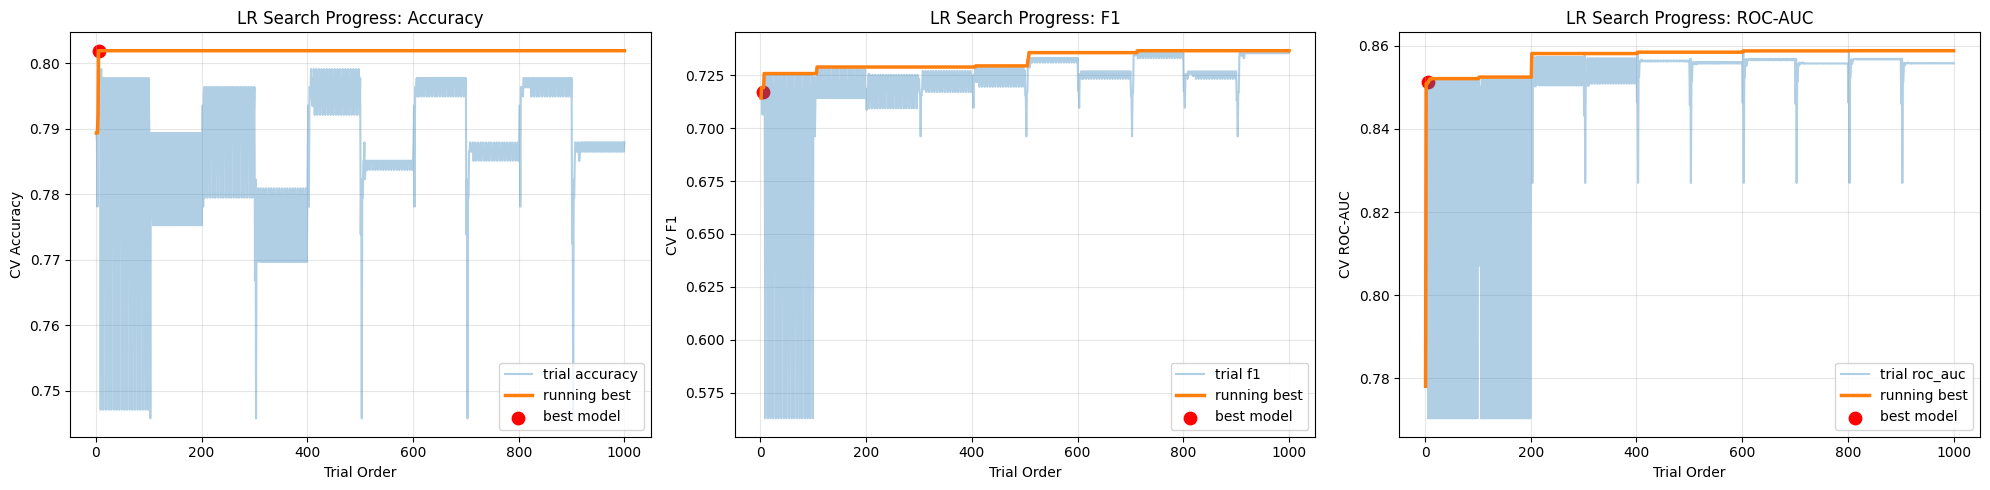


max_iter 摘要（mean / best）:


,max_iter,mean_accuracy,best_accuracy
0,1,0.781266,0.801950
1,6,0.788337,0.799163
2,11,0.788253,0.799163
3,16,0.788365,0.799163
4,21,0.788337,0.799163
5,26,0.788337,0.799163
6,31,0.788337,0.799163
7,36,0.788337,0.799163
8,41,0.788337,0.799163
9,46,0.788337,0.799163


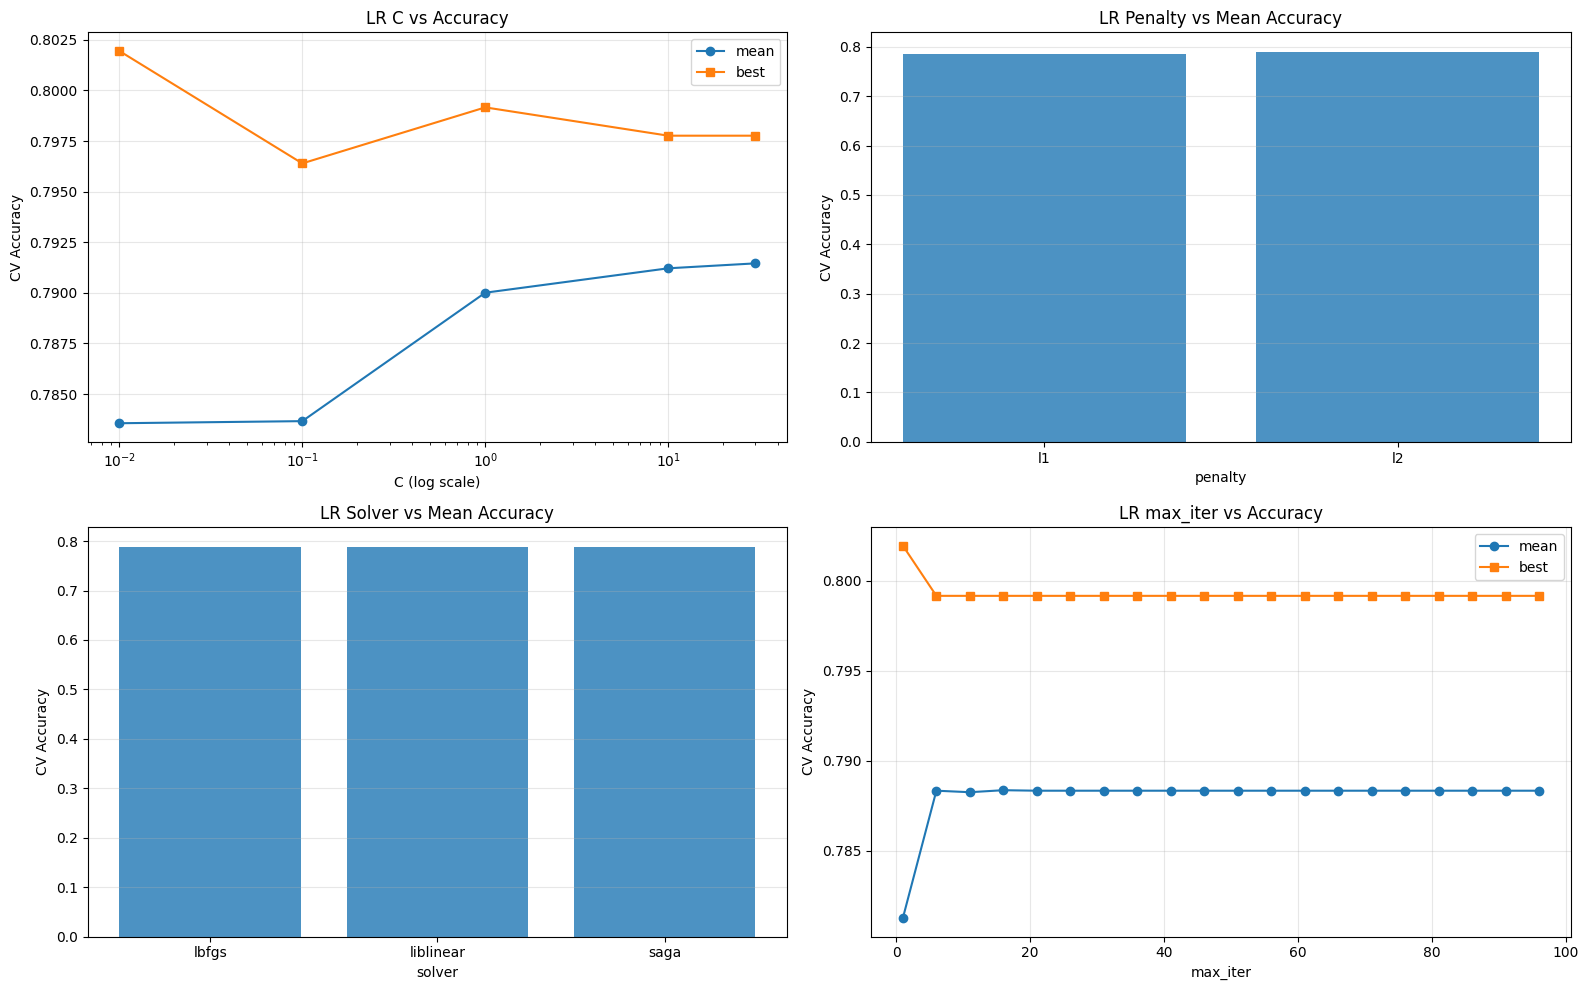


已輸出: logistic_regression_search_results.csv, logistic_regression_best_result.csv


In [10]:
from sklearn.model_selection import ParameterGrid
import warnings

warnings.filterwarnings("ignore", message=".*penalty.*deprecated.*", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*Inconsistent values: penalty.*", category=UserWarning)

base_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0, 30.0],
    "model__class_weight": [None, "balanced"],
    "model__max_iter": list(range(1, 101, 5)),
}

solver_penalty_pairs = [
    ("liblinear", "l1"),
    ("liblinear", "l2"),
    ("lbfgs", "l2"),
    ("saga", "l1"),
    ("saga", "l2"),
]

lr_param_candidates = []
for base in ParameterGrid(base_grid):
    for solver, penalty in solver_penalty_pairs:
        candidate = dict(base)
        candidate.update({
            "model__solver": solver,
            "model__penalty": penalty,
        })
        lr_param_candidates.append(candidate)

lr_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_search_rows = []

print("開始執行 Logistic Regression 參數搜尋...")
print(f"總組合數: {len(lr_param_candidates)}")

for idx, p in enumerate(lr_param_candidates, start=1):
    lr_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42)),
    ])
    lr_model.set_params(**p)

    lr_cv_result = cross_validate(
        lr_model,
        X_train,
        y_train,
        cv=lr_cv,
        scoring=["accuracy", "f1", "roc_auc"],
        n_jobs=-1,
    )

    lr_model.fit(X_train, y_train)
    lr_search_rows.append({
        "trial": idx,
        "C": p["model__C"],
        "penalty": p["model__penalty"],
        "solver": p["model__solver"],
        "max_iter": p["model__max_iter"],
        "class_weight": "None" if p["model__class_weight"] is None else p["model__class_weight"],
        "params": p,
        "cv_accuracy_mean": np.mean(lr_cv_result["test_accuracy"]),
        "cv_accuracy_std": np.std(lr_cv_result["test_accuracy"]),
        "cv_f1_mean": np.mean(lr_cv_result["test_f1"]),
        "cv_roc_auc_mean": np.mean(lr_cv_result["test_roc_auc"]),
    })

lr_search_df = pd.DataFrame(lr_search_rows)
lr_search_df["running_best_accuracy"] = lr_search_df["cv_accuracy_mean"].cummax()
lr_search_df["running_best_f1"] = lr_search_df["cv_f1_mean"].cummax()
lr_search_df["running_best_roc_auc"] = lr_search_df["cv_roc_auc_mean"].cummax()

lr_search_df = lr_search_df.sort_values(
    by=["cv_accuracy_mean", "cv_f1_mean", "cv_roc_auc_mean"],
    ascending=False,
).reset_index(drop=True)
lr_search_df["rank"] = np.arange(1, len(lr_search_df) + 1)

print("\nLogistic Regression 參數搜尋 Top 10:")
display(
    lr_search_df[[
        "rank",
        "trial",
        "C",
        "penalty",
        "solver",
        "max_iter",
        "class_weight",
        "cv_accuracy_mean",
        "cv_f1_mean",
        "cv_roc_auc_mean",
    ]].head(10)
)

lr_best_params = lr_search_df.loc[0, "params"]
print("\nLogistic Regression 最佳參數:")
print(lr_best_params)

best_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42)),
])
best_lr.set_params(**lr_best_params)
best_lr.fit(X_train, y_train)

lr_y_pred = best_lr.predict(X_valid)
lr_y_score = best_lr.predict_proba(X_valid)[:, 1]

lr_result = {
    "Model": "Logistic Regression",
    "Best_Params": lr_best_params,
    "Valid_Accuracy": accuracy_score(y_valid, lr_y_pred),
    "Valid_Precision": precision_score(y_valid, lr_y_pred, zero_division=0),
    "Valid_Recall": recall_score(y_valid, lr_y_pred, zero_division=0),
    "Valid_F1": f1_score(y_valid, lr_y_pred, zero_division=0),
    "Valid_ROC_AUC": roc_auc_score(y_valid, lr_y_score),
    "Confusion_Matrix": confusion_matrix(y_valid, lr_y_pred),
    "Classification_Report": classification_report(y_valid, lr_y_pred, digits=4),
}

print("\nLogistic Regression 最佳模型驗證結果")
print(f"Accuracy : {lr_result['Valid_Accuracy']:.4f}")
print(f"Precision: {lr_result['Valid_Precision']:.4f}")
print(f"Recall   : {lr_result['Valid_Recall']:.4f}")
print(f"F1       : {lr_result['Valid_F1']:.4f}")
print(f"ROC-AUC  : {lr_result['Valid_ROC_AUC']:.4f}")

print("\nConfusion Matrix:")
print(lr_result["Confusion_Matrix"])
print("\nClassification Report:")
print(lr_result["Classification_Report"])

lr_coef = best_lr.named_steps["model"].coef_[0]
lr_coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lr_coef,
    "abs_coefficient": np.abs(lr_coef),
}).sort_values("abs_coefficient", ascending=False)

print("\nLogistic Regression 係數重要性:")
display(lr_coef_df)

lr_best_row = lr_search_df.iloc[0]
lr_progress_df = lr_search_df.sort_values("trial")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(lr_progress_df["trial"], lr_progress_df["cv_accuracy_mean"], alpha=0.35, label="trial accuracy")
axes[0].plot(lr_progress_df["trial"], lr_progress_df["running_best_accuracy"], linewidth=2.5, label="running best")
axes[0].scatter(lr_best_row["trial"], lr_best_row["cv_accuracy_mean"], color="red", s=80, label="best model")
axes[0].set_title("LR Search Progress: Accuracy")
axes[0].set_xlabel("Trial Order")
axes[0].set_ylabel("CV Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(lr_progress_df["trial"], lr_progress_df["cv_f1_mean"], alpha=0.35, label="trial f1")
axes[1].plot(lr_progress_df["trial"], lr_progress_df["running_best_f1"], linewidth=2.5, label="running best")
axes[1].scatter(lr_best_row["trial"], lr_best_row["cv_f1_mean"], color="red", s=80, label="best model")
axes[1].set_title("LR Search Progress: F1")
axes[1].set_xlabel("Trial Order")
axes[1].set_ylabel("CV F1")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(lr_progress_df["trial"], lr_progress_df["cv_roc_auc_mean"], alpha=0.35, label="trial roc_auc")
axes[2].plot(lr_progress_df["trial"], lr_progress_df["running_best_roc_auc"], linewidth=2.5, label="running best")
axes[2].scatter(lr_best_row["trial"], lr_best_row["cv_roc_auc_mean"], color="red", s=80, label="best model")
axes[2].set_title("LR Search Progress: ROC-AUC")
axes[2].set_xlabel("Trial Order")
axes[2].set_ylabel("CV ROC-AUC")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

lr_c_summary = (
    lr_search_df.groupby("C", as_index=False)
    .agg(
        mean_accuracy=("cv_accuracy_mean", "mean"),
        best_accuracy=("cv_accuracy_mean", "max"),
    )
    .sort_values("C")
)

lr_penalty_summary = (
    lr_search_df.groupby("penalty", as_index=False)
    .agg(
        mean_accuracy=("cv_accuracy_mean", "mean"),
        best_accuracy=("cv_accuracy_mean", "max"),
    )
)

lr_solver_summary = (
    lr_search_df.groupby("solver", as_index=False)
    .agg(
        mean_accuracy=("cv_accuracy_mean", "mean"),
        best_accuracy=("cv_accuracy_mean", "max"),
    )
)

lr_iter_summary = (
    lr_search_df.groupby("max_iter", as_index=False)
    .agg(
        mean_accuracy=("cv_accuracy_mean", "mean"),
        best_accuracy=("cv_accuracy_mean", "max"),
    )
    .sort_values("max_iter")
)

print("\nmax_iter 摘要（mean / best）:")
display(lr_iter_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(lr_c_summary["C"], lr_c_summary["mean_accuracy"], marker="o", label="mean")
axes[0, 0].plot(lr_c_summary["C"], lr_c_summary["best_accuracy"], marker="s", label="best")
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("LR C vs Accuracy")
axes[0, 0].set_xlabel("C (log scale)")
axes[0, 0].set_ylabel("CV Accuracy")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].bar(lr_penalty_summary["penalty"], lr_penalty_summary["mean_accuracy"], alpha=0.8)
axes[0, 1].set_title("LR Penalty vs Mean Accuracy")
axes[0, 1].set_xlabel("penalty")
axes[0, 1].set_ylabel("CV Accuracy")
axes[0, 1].grid(axis="y", alpha=0.3)

axes[1, 0].bar(lr_solver_summary["solver"], lr_solver_summary["mean_accuracy"], alpha=0.8)
axes[1, 0].set_title("LR Solver vs Mean Accuracy")
axes[1, 0].set_xlabel("solver")
axes[1, 0].set_ylabel("CV Accuracy")
axes[1, 0].grid(axis="y", alpha=0.3)

axes[1, 1].plot(lr_iter_summary["max_iter"], lr_iter_summary["mean_accuracy"], marker="o", label="mean")
axes[1, 1].plot(lr_iter_summary["max_iter"], lr_iter_summary["best_accuracy"], marker="s", label="best")
axes[1, 1].set_title("LR max_iter vs Accuracy")
axes[1, 1].set_xlabel("max_iter")
axes[1, 1].set_ylabel("CV Accuracy")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

lr_search_df.to_csv("logistic_regression_search_results.csv", index=False, encoding="utf-8-sig")
pd.DataFrame([{
    "model": lr_result["Model"],
    "best_params": str(lr_result["Best_Params"]),
    "valid_accuracy": lr_result["Valid_Accuracy"],
    "valid_precision": lr_result["Valid_Precision"],
    "valid_recall": lr_result["Valid_Recall"],
    "valid_f1": lr_result["Valid_F1"],
    "valid_roc_auc": lr_result["Valid_ROC_AUC"],
}]).to_csv("logistic_regression_best_result.csv", index=False, encoding="utf-8-sig")

print("\n已輸出: logistic_regression_search_results.csv, logistic_regression_best_result.csv")

## Step 4: SVM 參數搜尋與最佳化

本區塊只執行 SVM，針對關鍵參數調整：
1. C（正則化強度）
2. kernel（linear / rbf）
3. gamma（rbf 專用）
4. class_weight（處理類別不平衡）
5. 以 5-fold CV Accuracy / F1 / ROC-AUC 選出最佳模型

開始執行 SVM 參數搜尋（四種 kernel, validation only）...
總組合數: 42

SVM 參數搜尋 Top 10:


,rank,trial,kernel,C,gamma,degree,coef0,class_weight,valid_accuracy,valid_f1,valid_roc_auc
0,1,14,rbf,1.0,0.1,None,None,balanced,0.826816,0.770370,0.842819
1,2,13,rbf,1.0,scale,None,None,balanced,0.826816,0.770370,0.842161
2,3,27,poly,10.0,scale,2,0.0,None,0.821229,0.753846,0.821344
3,4,25,poly,1.0,scale,2,0.0,balanced,0.821229,0.750000,0.848485
4,5,12,rbf,1.0,0.1,None,None,None,0.821229,0.741935,0.836891
5,6,24,poly,1.0,scale,3,0.0,None,0.821229,0.728814,0.838076
6,7,9,rbf,0.1,scale,None,None,balanced,0.810056,0.750000,0.829117
7,8,29,poly,10.0,scale,2,0.0,balanced,0.810056,0.746269,0.848880
8,9,11,rbf,1.0,scale,None,None,None,0.810056,0.725806,0.840580
9,10,15,rbf,10.0,scale,None,None,None,0.810056,0.725806,0.805665



SVM 全部 kernel 最佳參數:
{'model__C': 1.0, 'model__class_weight': 'balanced', 'model__gamma': 0.1, 'model__kernel': 'rbf'}

SVM 最佳模型驗證結果
Accuracy : 0.8268
Precision: 0.7879
Recall   : 0.7536
F1       : 0.7704
ROC-AUC  : 0.8428
SV Count : 354

Confusion Matrix:
[[96 14]
 [17 52]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8496    0.8727    0.8610       110
           1     0.7879    0.7536    0.7704        69

    accuracy                         0.8268       179
   macro avg     0.8187    0.8132    0.8157       179
weighted avg     0.8258    0.8268    0.8261       179


四種 kernel 最佳組合比較（已排序）:


,kernel_rank,kernel,C,gamma,degree,coef0,class_weight,valid_accuracy,valid_f1,valid_roc_auc
0,1,rbf,1.0,0.1,None,None,balanced,0.826816,0.770370,0.842819
1,2,poly,10.0,scale,2,0.0,None,0.821229,0.753846,0.821344
2,3,linear,1.0,None,None,None,None,0.793296,0.713178,0.810804
3,4,sigmoid,0.1,0.1,None,0.0,balanced,0.770950,0.691729,0.763109


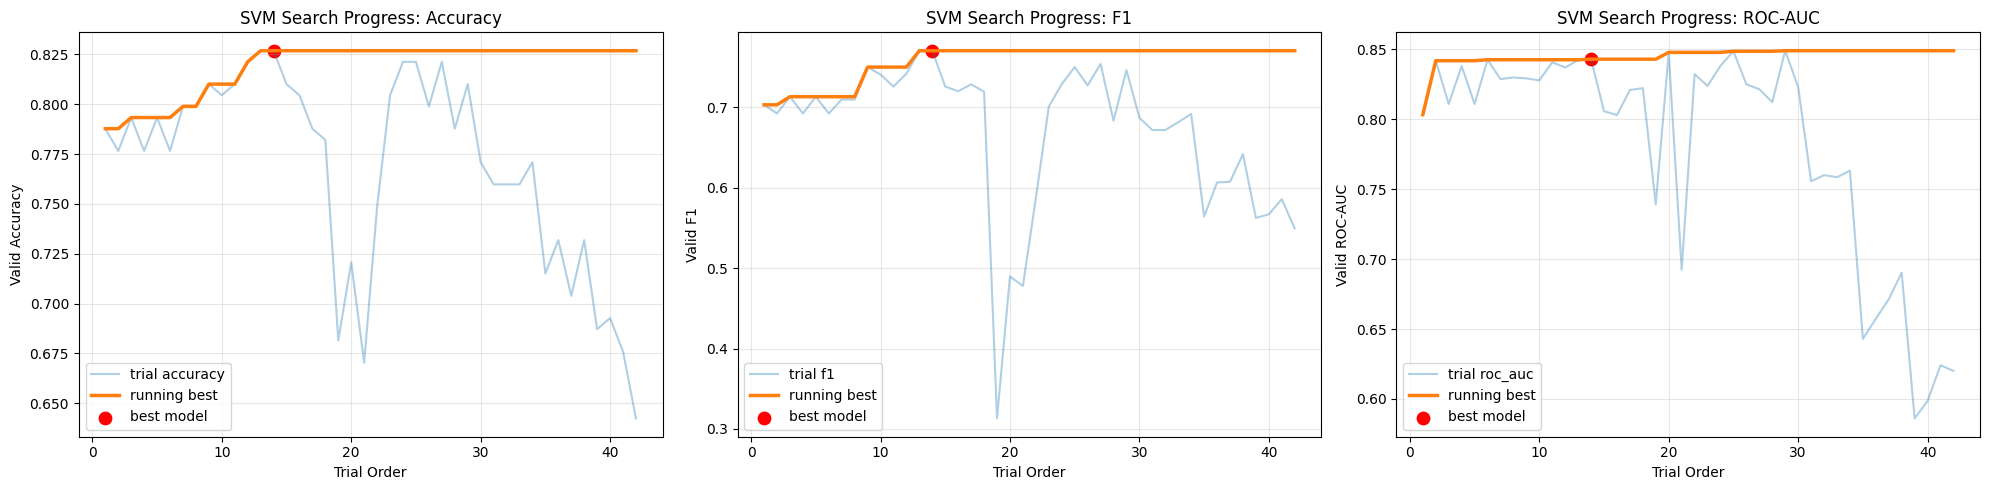


SVM kernel 摘要（mean / best）:


,kernel,mean_accuracy,best_accuracy
0,linear,0.783985,0.793296
1,poly,0.771415,0.821229
2,rbf,0.806797,0.826816
3,sigmoid,0.719274,0.770950



SVM gamma 摘要（適用 kernel）:


,kernel,gamma,mean_accuracy,best_accuracy
0,poly,scale,0.771415,0.821229
1,rbf,0.1,0.806331,0.826816
2,rbf,scale,0.807263,0.826816
3,sigmoid,0.1,0.721601,0.770950
4,sigmoid,scale,0.716946,0.759777


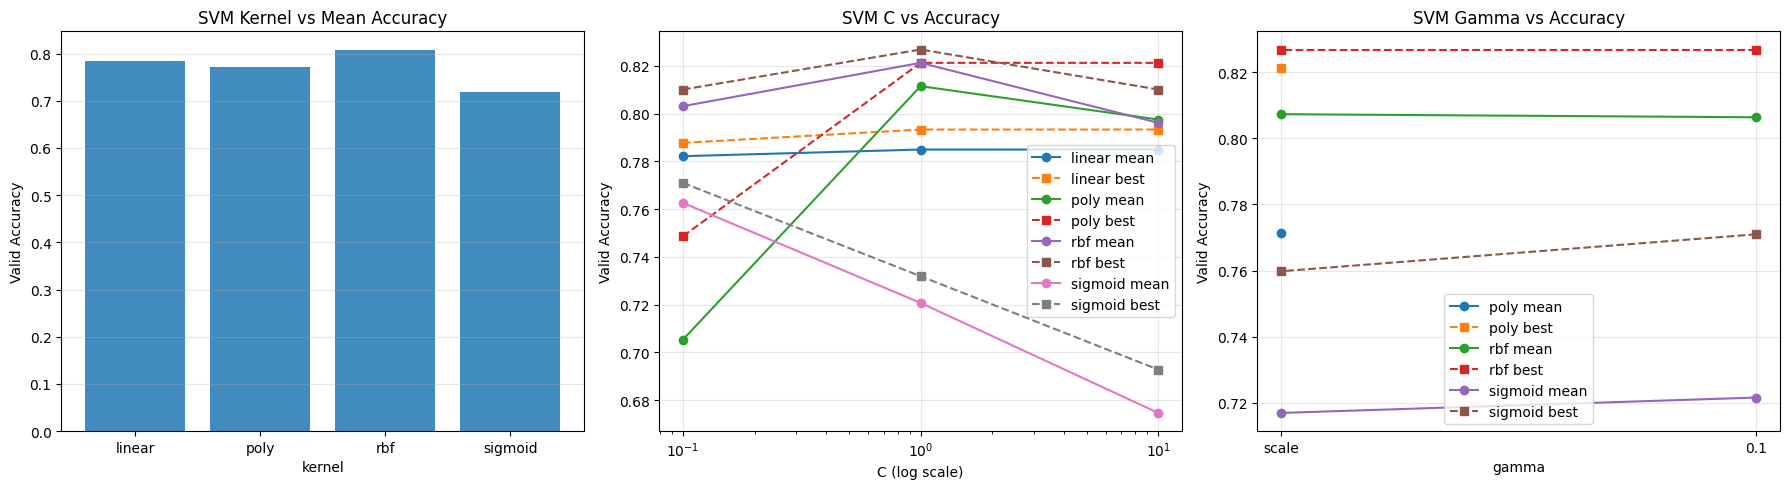


已輸出: svm_search_results.csv, svm_best_result.csv


In [14]:
from sklearn.model_selection import ParameterGrid

# 極速模式：四種 kernel 全比較，validation-only
svm_search_rows = []

linear_grid = {
    "model__kernel": ["linear"],
    "model__C": [0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"],
}

rbf_grid = {
    "model__kernel": ["rbf"],
    "model__C": [0.1, 1.0, 10.0],
    "model__gamma": ["scale", 0.1],
    "model__class_weight": [None, "balanced"],
}

poly_grid = {
    "model__kernel": ["poly"],
    "model__C": [0.1, 1.0, 10.0],
    "model__degree": [2, 3],
    "model__gamma": ["scale"],
    "model__coef0": [0.0],
    "model__class_weight": [None, "balanced"],
}

sigmoid_grid = {
    "model__kernel": ["sigmoid"],
    "model__C": [0.1, 1.0, 10.0],
    "model__gamma": ["scale", 0.1],
    "model__coef0": [0.0],
    "model__class_weight": [None, "balanced"],
}

svm_param_candidates = (
    list(ParameterGrid(linear_grid))
    + list(ParameterGrid(rbf_grid))
    + list(ParameterGrid(poly_grid))
    + list(ParameterGrid(sigmoid_grid))
)

print("開始執行 SVM 參數搜尋（四種 kernel, validation only）...")
print(f"總組合數: {len(svm_param_candidates)}")

for idx, p in enumerate(svm_param_candidates, start=1):
    svm_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(random_state=42)),
    ])
    svm_model.set_params(**p)
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_valid)
    y_score = svm_model.decision_function(X_valid)

    svm_search_rows.append({
        "trial": idx,
        "kernel": p["model__kernel"],
        "C": p["model__C"],
        "gamma": p.get("model__gamma", "None"),
        "degree": p.get("model__degree", "None"),
        "coef0": p.get("model__coef0", "None"),
        "class_weight": "None" if p["model__class_weight"] is None else p["model__class_weight"],
        "params": p,
        "valid_accuracy": accuracy_score(y_valid, y_pred),
        "valid_f1": f1_score(y_valid, y_pred, zero_division=0),
        "valid_roc_auc": roc_auc_score(y_valid, y_score),
    })

svm_search_df = pd.DataFrame(svm_search_rows)
svm_search_df["running_best_accuracy"] = svm_search_df["valid_accuracy"].cummax()
svm_search_df["running_best_f1"] = svm_search_df["valid_f1"].cummax()
svm_search_df["running_best_roc_auc"] = svm_search_df["valid_roc_auc"].cummax()

svm_search_df = svm_search_df.sort_values(
    by=["valid_accuracy", "valid_f1", "valid_roc_auc"],
    ascending=False,
).reset_index(drop=True)
svm_search_df["rank"] = np.arange(1, len(svm_search_df) + 1)

print("\nSVM 參數搜尋 Top 10:")
display(
    svm_search_df[[
        "rank",
        "trial",
        "kernel",
        "C",
        "gamma",
        "degree",
        "coef0",
        "class_weight",
        "valid_accuracy",
        "valid_f1",
        "valid_roc_auc",
    ]].head(10)
)

svm_best_params = svm_search_df.loc[0, "params"]
print("\nSVM 全部 kernel 最佳參數:")
print(svm_best_params)

best_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=42)),
])
best_svm.set_params(**svm_best_params)
best_svm.fit(X_train, y_train)

svm_y_pred = best_svm.predict(X_valid)
svm_y_score = best_svm.decision_function(X_valid)

svm_result = {
    "Model": "SVM",
    "Best_Params": svm_best_params,
    "Valid_Accuracy": accuracy_score(y_valid, svm_y_pred),
    "Valid_Precision": precision_score(y_valid, svm_y_pred, zero_division=0),
    "Valid_Recall": recall_score(y_valid, svm_y_pred, zero_division=0),
    "Valid_F1": f1_score(y_valid, svm_y_pred, zero_division=0),
    "Valid_ROC_AUC": roc_auc_score(y_valid, svm_y_score),
    "Support_Vector_Count": int(best_svm.named_steps["model"].n_support_.sum()),
    "Confusion_Matrix": confusion_matrix(y_valid, svm_y_pred),
    "Classification_Report": classification_report(y_valid, svm_y_pred, digits=4),
}

print("\nSVM 最佳模型驗證結果")
print(f"Accuracy : {svm_result['Valid_Accuracy']:.4f}")
print(f"Precision: {svm_result['Valid_Precision']:.4f}")
print(f"Recall   : {svm_result['Valid_Recall']:.4f}")
print(f"F1       : {svm_result['Valid_F1']:.4f}")
print(f"ROC-AUC  : {svm_result['Valid_ROC_AUC']:.4f}")
print(f"SV Count : {svm_result['Support_Vector_Count']}")

print("\nConfusion Matrix:")
print(svm_result["Confusion_Matrix"])
print("\nClassification Report:")
print(svm_result["Classification_Report"] )

# 每個 kernel 的最佳結果與排名
kernel_best_df = (
    svm_search_df.sort_values(
        by=["valid_accuracy", "valid_f1", "valid_roc_auc"],
        ascending=False,
    )
    .groupby("kernel", as_index=False)
    .first()
    .sort_values(by=["valid_accuracy", "valid_f1", "valid_roc_auc"], ascending=False)
    .reset_index(drop=True)
)
kernel_best_df["kernel_rank"] = np.arange(1, len(kernel_best_df) + 1)

print("\n四種 kernel 最佳組合比較（已排序）:")
display(
    kernel_best_df[[
        "kernel_rank",
        "kernel",
        "C",
        "gamma",
        "degree",
        "coef0",
        "class_weight",
        "valid_accuracy",
        "valid_f1",
        "valid_roc_auc",
    ]]
)

svm_best_row = svm_search_df.iloc[0]
svm_progress_df = svm_search_df.sort_values("trial")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(svm_progress_df["trial"], svm_progress_df["valid_accuracy"], alpha=0.35, label="trial accuracy")
axes[0].plot(svm_progress_df["trial"], svm_progress_df["running_best_accuracy"], linewidth=2.5, label="running best")
axes[0].scatter(svm_best_row["trial"], svm_best_row["valid_accuracy"], color="red", s=80, label="best model")
axes[0].set_title("SVM Search Progress: Accuracy")
axes[0].set_xlabel("Trial Order")
axes[0].set_ylabel("Valid Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(svm_progress_df["trial"], svm_progress_df["valid_f1"], alpha=0.35, label="trial f1")
axes[1].plot(svm_progress_df["trial"], svm_progress_df["running_best_f1"], linewidth=2.5, label="running best")
axes[1].scatter(svm_best_row["trial"], svm_best_row["valid_f1"], color="red", s=80, label="best model")
axes[1].set_title("SVM Search Progress: F1")
axes[1].set_xlabel("Trial Order")
axes[1].set_ylabel("Valid F1")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(svm_progress_df["trial"], svm_progress_df["valid_roc_auc"], alpha=0.35, label="trial roc_auc")
axes[2].plot(svm_progress_df["trial"], svm_progress_df["running_best_roc_auc"], linewidth=2.5, label="running best")
axes[2].scatter(svm_best_row["trial"], svm_best_row["valid_roc_auc"], color="red", s=80, label="best model")
axes[2].set_title("SVM Search Progress: ROC-AUC")
axes[2].set_xlabel("Trial Order")
axes[2].set_ylabel("Valid ROC-AUC")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

svm_kernel_summary = (
    svm_search_df.groupby("kernel", as_index=False)
    .agg(
        mean_accuracy=("valid_accuracy", "mean"),
        best_accuracy=("valid_accuracy", "max"),
    )
)

svm_c_summary = (
    svm_search_df.groupby(["kernel", "C"], as_index=False)
    .agg(
        mean_accuracy=("valid_accuracy", "mean"),
        best_accuracy=("valid_accuracy", "max"),
    )
    .sort_values(["kernel", "C"])
)

svm_gamma_summary = (
    svm_search_df[svm_search_df["kernel"].isin(["rbf", "sigmoid", "poly"])]
    .groupby(["kernel", "gamma"], as_index=False)
    .agg(
        mean_accuracy=("valid_accuracy", "mean"),
        best_accuracy=("valid_accuracy", "max"),
    )
)

print("\nSVM kernel 摘要（mean / best）:")
display(svm_kernel_summary)
print("\nSVM gamma 摘要（適用 kernel）:")
display(svm_gamma_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(svm_kernel_summary["kernel"], svm_kernel_summary["mean_accuracy"], alpha=0.85)
axes[0].set_title("SVM Kernel vs Mean Accuracy")
axes[0].set_xlabel("kernel")
axes[0].set_ylabel("Valid Accuracy")
axes[0].grid(axis="y", alpha=0.3)

for kernel_name, group_df in svm_c_summary.groupby("kernel"):
    axes[1].plot(group_df["C"], group_df["mean_accuracy"], marker="o", label=f"{kernel_name} mean")
    axes[1].plot(group_df["C"], group_df["best_accuracy"], marker="s", linestyle="--", label=f"{kernel_name} best")
axes[1].set_xscale("log")
axes[1].set_title("SVM C vs Accuracy")
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("Valid Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

for kernel_name, group_df in svm_gamma_summary.groupby("kernel"):
    axes[2].plot(
        group_df["gamma"].astype(str),
        group_df["mean_accuracy"],
        marker="o",
        label=f"{kernel_name} mean",
    )
    axes[2].plot(
        group_df["gamma"].astype(str),
        group_df["best_accuracy"],
        marker="s",
        linestyle="--",
        label=f"{kernel_name} best",
    )
axes[2].set_title("SVM Gamma vs Accuracy")
axes[2].set_xlabel("gamma")
axes[2].set_ylabel("Valid Accuracy")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

svm_search_df.to_csv("svm_search_results.csv", index=False, encoding="utf-8-sig")
pd.DataFrame([{
    "model": svm_result["Model"],
    "best_params": str(svm_result["Best_Params"]),
    "valid_accuracy": svm_result["Valid_Accuracy"],
    "valid_precision": svm_result["Valid_Precision"],
    "valid_recall": svm_result["Valid_Recall"],
    "valid_f1": svm_result["Valid_F1"],
    "valid_roc_auc": svm_result["Valid_ROC_AUC"],
    "support_vector_count": svm_result["Support_Vector_Count"],
}]).to_csv("svm_best_result.csv", index=False, encoding="utf-8-sig")

print("\n已輸出: svm_search_results.csv, svm_best_result.csv")

## Step 5: KNN 參數搜尋與最佳化

本區塊只執行 KNN，針對關鍵參數調整：
1. n_neighbors（鄰居數）
2. weights（uniform / distance）
3. p（距離：1=Manhattan, 2=Euclidean）
4. 以 validation set 快速比較 Accuracy / F1 / ROC-AUC，選出最佳模型

KNN Top 10 組合（依 F1 / Accuracy / ROC-AUC 排序）
   n_neighbors   weights  p  accuracy  precision    recall        f1   roc_auc
0            5  distance  1  0.821229   0.768116  0.768116  0.768116  0.859552
1            7  distance  2  0.821229   0.768116  0.768116  0.768116  0.859420
2            7   uniform  2  0.821229   0.768116  0.768116  0.768116  0.858498
3           21  distance  1  0.821229   0.776119  0.753623  0.764706  0.852306
4           15  distance  1  0.826816   0.806452  0.724638  0.763359  0.859420
5           13  distance  2  0.826816   0.806452  0.724638  0.763359  0.855797
6            3  distance  1  0.815642   0.757143  0.768116  0.762590  0.849802
7           11  distance  2  0.821229   0.784615  0.739130  0.761194  0.856917
8           19   uniform  2  0.826816   0.816667  0.710145  0.759690  0.852701
9            9  distance  1  0.815642   0.764706  0.753623  0.759124  0.854414

KNN 最佳參數： {'knn__n_neighbors': 5, 'knn__weights': 'distance', 'knn__p': 1}
KNN 最佳模型驗證結

/var/folders/1x/c1_602pn4hd7y4fg4c3zfgqh0000gn/T/ipykernel_35688/3520798234.py:96: UserWarning: Glyph 21443 (\N{CJK UNIFIED IDEOGRAPH-53C3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1x/c1_602pn4hd7y4fg4c3zfgqh0000gn/T/ipykernel_35688/3520798234.py:96: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1x/c1_602pn4hd7y4fg4c3zfgqh0000gn/T/ipykernel_35688/3520798234.py:96: UserWarning: Glyph 32068 (\N{CJK UNIFIED IDEOGRAPH-7D44}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1x/c1_602pn4hd7y4fg4c3zfgqh0000gn/T/ipykernel_35688/3520798234.py:96: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1x/c1_602pn4hd7y4fg4c3zfgqh0000gn/T/ipykernel_35688/3520798234.py:96: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1x/c1_6

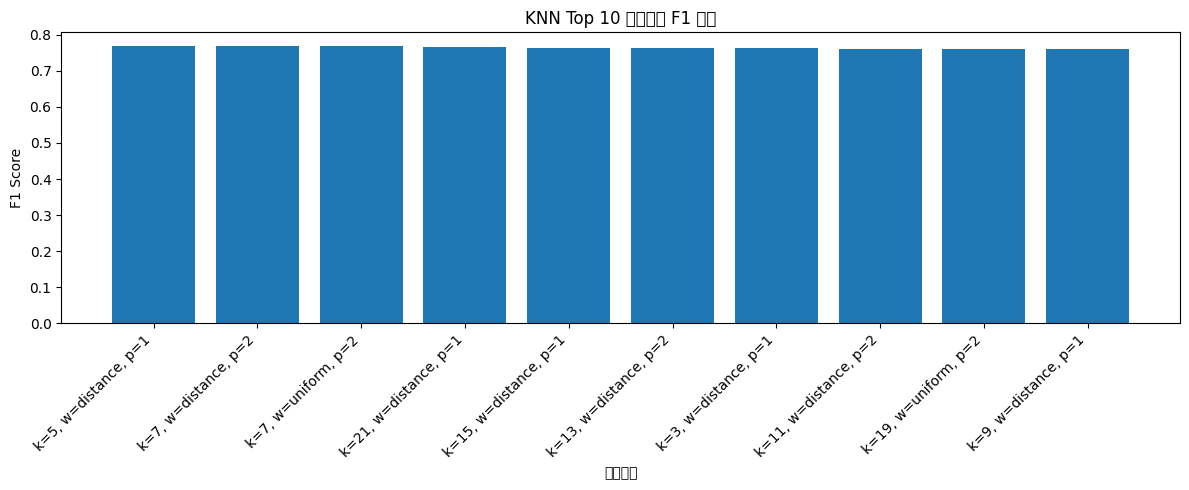

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

# KNN 需要標準化，避免不同特徵尺度造成距離計算偏差
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
}

search_results_knn = []

for params in ParameterGrid(param_grid_knn):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ])
    model.set_params(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)[:, 1]

    search_results_knn.append({
        'n_neighbors': params['knn__n_neighbors'],
        'weights': params['knn__weights'],
        'p': params['knn__p'],
        'accuracy': accuracy_score(y_valid, y_pred),
        'precision': precision_score(y_valid, y_pred, zero_division=0),
        'recall': recall_score(y_valid, y_pred, zero_division=0),
        'f1': f1_score(y_valid, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_valid, y_proba),
    })

knn_results_df = pd.DataFrame(search_results_knn)
knn_results_df = knn_results_df.sort_values(by=['f1', 'accuracy', 'roc_auc'], ascending=False).reset_index(drop=True)

best_knn = knn_results_df.iloc[0]
best_params_knn = {
    'knn__n_neighbors': int(best_knn['n_neighbors']),
    'knn__weights': best_knn['weights'],
    'knn__p': int(best_knn['p']),
}

best_knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
best_knn_model.set_params(**best_params_knn)
best_knn_model.fit(X_train, y_train)

y_pred_best_knn = best_knn_model.predict(X_valid)
y_proba_best_knn = best_knn_model.predict_proba(X_valid)[:, 1]

knn_best_result_df = pd.DataFrame([{
    'model': 'KNN',
    'best_n_neighbors': best_params_knn['knn__n_neighbors'],
    'best_weights': best_params_knn['knn__weights'],
    'best_p': best_params_knn['knn__p'],
    'accuracy': accuracy_score(y_valid, y_pred_best_knn),
    'precision': precision_score(y_valid, y_pred_best_knn, zero_division=0),
    'recall': recall_score(y_valid, y_pred_best_knn, zero_division=0),
    'f1': f1_score(y_valid, y_pred_best_knn, zero_division=0),
    'roc_auc': roc_auc_score(y_valid, y_proba_best_knn),
}])

knn_results_df.to_csv('knn_search_results.csv', index=False)
knn_best_result_df.to_csv('knn_best_result.csv', index=False)

print('KNN Top 10 組合（依 F1 / Accuracy / ROC-AUC 排序）')
print(knn_results_df.head(10))
print('\nKNN 最佳參數：', best_params_knn)
print('KNN 最佳模型驗證結果：')
print(knn_best_result_df)
print('\n已輸出：knn_search_results.csv、knn_best_result.csv')

# 視覺化：Top 10 F1 比較
plot_df = knn_results_df.head(10).copy()
plot_df['label'] = (
    'k=' + plot_df['n_neighbors'].astype(int).astype(str) +
    ', w=' + plot_df['weights'].astype(str) +
    ', p=' + plot_df['p'].astype(int).astype(str)
)

plt.figure(figsize=(12, 5))
plt.bar(plot_df['label'], plot_df['f1'])
plt.title('KNN Top 10 參數組合 F1 比較')
plt.xlabel('參數組合')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 5-2: 用折線圖判斷 K 值

> 方法：對每個 k，把不同 `weights` 與 `p` 的結果取平均，觀察整體趨勢。

> 判斷原則：
1. 優先看 F1（分類平衡性）
2. 再看 ROC-AUC（排序能力）
3. 若多個 k 很接近，選較小的 k（模型較敏感、可讀性高）或平滑區的中間值（較穩定）

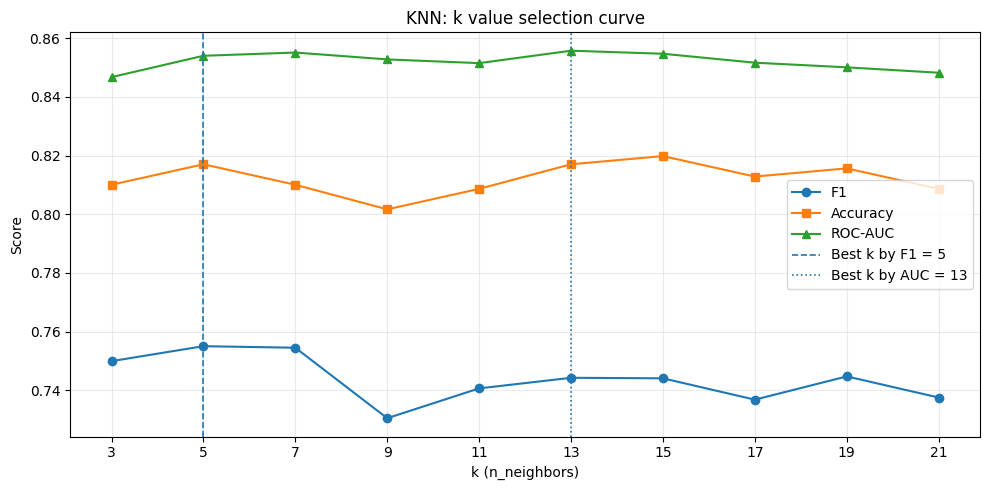

k 的平均指標趨勢表：
   n_neighbors  accuracy        f1   roc_auc
0            3  0.810056  0.749913  0.846756
1            5  0.817039  0.755013  0.854035
2            7  0.810056  0.754483  0.855138
3            9  0.801676  0.730454  0.852800
4           11  0.808659  0.740623  0.851532
5           13  0.817039  0.744234  0.855764
6           15  0.819832  0.744055  0.854727
7           17  0.812849  0.736778  0.851680
8           19  0.815642  0.744706  0.850099
9           21  0.808659  0.737511  0.848254

建議 1（F1 最佳）: k = 5
建議 2（ROC-AUC 最佳）: k = 13
整體建議可在 k = 5 與 k = 13 間選擇，依你重視的指標決定。


In [17]:
import matplotlib.pyplot as plt

# 對每個 k 聚合（平均）指標，避免只看單一 weights/p 組合
k_curve_df = (
    knn_results_df
    .groupby('n_neighbors', as_index=False)[['accuracy', 'f1', 'roc_auc']]
    .mean()
    .sort_values('n_neighbors')
)

best_k_by_f1 = int(k_curve_df.loc[k_curve_df['f1'].idxmax(), 'n_neighbors'])
best_k_by_auc = int(k_curve_df.loc[k_curve_df['roc_auc'].idxmax(), 'n_neighbors'])

plt.figure(figsize=(10, 5))
plt.plot(k_curve_df['n_neighbors'], k_curve_df['f1'], marker='o', label='F1')
plt.plot(k_curve_df['n_neighbors'], k_curve_df['accuracy'], marker='s', label='Accuracy')
plt.plot(k_curve_df['n_neighbors'], k_curve_df['roc_auc'], marker='^', label='ROC-AUC')

plt.axvline(best_k_by_f1, linestyle='--', linewidth=1.2, label=f'Best k by F1 = {best_k_by_f1}')
plt.axvline(best_k_by_auc, linestyle=':', linewidth=1.2, label=f'Best k by AUC = {best_k_by_auc}')

plt.title('KNN: k value selection curve')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Score')
plt.xticks(k_curve_df['n_neighbors'])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print('k 的平均指標趨勢表：')
print(k_curve_df)
print(f'\n建議 1（F1 最佳）: k = {best_k_by_f1}')
print(f'建議 2（ROC-AUC 最佳）: k = {best_k_by_auc}')

if best_k_by_f1 == best_k_by_auc:
    print(f'整體建議 k = {best_k_by_f1}（F1 與 AUC 一致）')
else:
    print(f'整體建議可在 k = {best_k_by_f1} 與 k = {best_k_by_auc} 間選擇，依你重視的指標決定。')

## Step 6: 五大指標綜合比較與最終決策

比較指標：
1. Accuracy
2. Precision
3. Recall
4. F1
5. ROC-AUC

決策方式：
- 先彙整各模型五項指標
- 對每個指標做 Min-Max 正規化
- 取五個正規化分數平均為 `composite_score`
- `composite_score` 最高者視為綜合最佳模型

模型五指標比較與綜合排名：
   rank                model  accuracy  precision    recall        f1  \
0     1                  KNN  0.821229   0.768116  0.768116  0.768116   
1     2                  SVM  0.826816   0.787879  0.753623  0.770370   
2     3  Logistic Regression  0.810056   0.843137  0.623188  0.716667   
3     4        Random Forest  0.793296   0.728571  0.739130  0.733813   
4     5           GaussianNB  0.782123   0.714286  0.724638  0.719424   
5     6        Decision Tree  0.787709   0.816327  0.579710  0.677966   

    roc_auc  composite_score  
0  0.859552         0.853674  
1  0.842819         0.850325  
2  0.835310         0.584621  
3  0.842029         0.511468  
4  0.819368         0.327055  
5  0.790580         0.183385  

綜合最佳模型：
KNN (composite_score=0.8537)


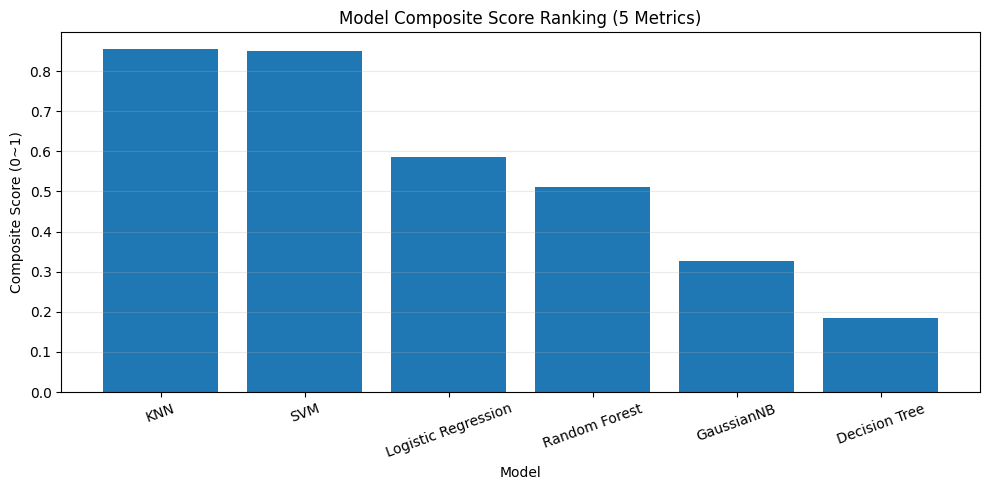


已輸出：model_comparison_summary.csv


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rows = []

def add_model_row(model_name, acc, prec, rec, f1, auc):
    rows.append({
        'model': model_name,
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'roc_auc': float(auc),
    })

# 1) 既有模型結果（若已存在於記憶體）
if 'dt_result' in globals():
    add_model_row('Decision Tree', dt_result['Valid_Accuracy'], dt_result['Valid_Precision'], dt_result['Valid_Recall'], dt_result['Valid_F1'], dt_result['Valid_ROC_AUC'])

if 'rf_result' in globals():
    add_model_row('Random Forest', rf_result['Valid_Accuracy'], rf_result['Valid_Precision'], rf_result['Valid_Recall'], rf_result['Valid_F1'], rf_result['Valid_ROC_AUC'])

if 'lr_result' in globals():
    add_model_row('Logistic Regression', lr_result['Valid_Accuracy'], lr_result['Valid_Precision'], lr_result['Valid_Recall'], lr_result['Valid_F1'], lr_result['Valid_ROC_AUC'])

if 'svm_result' in globals():
    add_model_row('SVM', svm_result['Valid_Accuracy'], svm_result['Valid_Precision'], svm_result['Valid_Recall'], svm_result['Valid_F1'], svm_result['Valid_ROC_AUC'])

if 'knn_best_result_df' in globals() and len(knn_best_result_df) > 0:
    r = knn_best_result_df.iloc[0]
    add_model_row('KNN', r['accuracy'], r['precision'], r['recall'], r['f1'], r['roc_auc'])

# 2) GaussianNB：若未建立結果就即時計算一次，避免比較缺模型
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
gnb_pred = gnb_model.predict(X_valid)
gnb_proba = gnb_model.predict_proba(X_valid)[:, 1]
add_model_row(
    'GaussianNB',
    accuracy_score(y_valid, gnb_pred),
    precision_score(y_valid, gnb_pred, zero_division=0),
    recall_score(y_valid, gnb_pred, zero_division=0),
    f1_score(y_valid, gnb_pred, zero_division=0),
    roc_auc_score(y_valid, gnb_proba),
)

comparison_df = pd.DataFrame(rows).drop_duplicates(subset=['model'], keep='last').reset_index(drop=True)
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# 3) Min-Max 正規化 + 綜合分數
for m in metrics:
    min_v = comparison_df[m].min()
    max_v = comparison_df[m].max()
    if np.isclose(max_v, min_v):
        comparison_df[f'{m}_norm'] = 1.0
    else:
        comparison_df[f'{m}_norm'] = (comparison_df[m] - min_v) / (max_v - min_v)

norm_cols = [f'{m}_norm' for m in metrics]
comparison_df['composite_score'] = comparison_df[norm_cols].mean(axis=1)

comparison_rank_df = comparison_df.sort_values(
    by=['composite_score', 'f1', 'roc_auc', 'accuracy'],
    ascending=False
).reset_index(drop=True)
comparison_rank_df['rank'] = np.arange(1, len(comparison_rank_df) + 1)

# 輸出最終比較表
comparison_rank_df.to_csv('model_comparison_summary.csv', index=False, encoding='utf-8-sig')

print('模型五指標比較與綜合排名：')
print(comparison_rank_df[['rank', 'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'composite_score']])

best_model_row = comparison_rank_df.iloc[0]
print('\n綜合最佳模型：')
print(f"{best_model_row['model']} (composite_score={best_model_row['composite_score']:.4f})")

# 視覺化：綜合分數長條圖
plt.figure(figsize=(10, 5))
plt.bar(comparison_rank_df['model'], comparison_rank_df['composite_score'])
plt.title('Model Composite Score Ranking (5 Metrics)')
plt.xlabel('Model')
plt.ylabel('Composite Score (0~1)')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('\n已輸出：model_comparison_summary.csv')